# Perbandingan Model: SARIMA vs SGBoost (Quarterly Earthquake Forecast)
Notebook ini membandingkan 2 model untuk target jumlah gempa triwulan: SARIMA dan SGBoost.
Output artifacts (split, model, prediksi, metadata) disimpan ke folder artifacts khusus.

In [24]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# Konfigurasi eksperimen
DATA_PATH = Path('data_gempa_kaggle/katalog_gempa_v2.tsv')
ARTIFACT_DIR = Path('artifacts/model_compare_sarima_sgboost')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MAG_THRESHOLD = 5.0
TARGET_COL = 'count_m5'  # opsi lain: count_all
TEST_QUARTERS = 8

# Parameter SARIMA awal (akan dipilih terbaik berdasarkan AIC dari grid kecil)
SARIMA_P = [0, 1, 2]
SARIMA_D = [0, 1]
SARIMA_Q = [0, 1, 2]
SARIMA_SP = [0, 1]
SARIMA_SD = [0, 1]
SARIMA_SQ = [0, 1]
SEASONAL_PERIOD = 4

# Fitur untuk SGBoost
LAGS = [1, 2, 4, 8]
ROLL_WINDOWS = [2, 4]

print('Artifact dir:', ARTIFACT_DIR.resolve())

Artifact dir: D:\Projects\bencana_dicoding_app\timeseries_triwulan\notebooks\timeseries_triwulan\artifacts\model_compare_sarima_sgboost


In [26]:
# Load data dan agregasi triwulan
df = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
df = df.dropna(subset=['datetime', 'magnitude']).copy()
df['datetime'] = df['datetime'].dt.tz_convert(None)

q_all = df.resample('QE', on='datetime').size().rename('count_all')
q_m5 = (df[df['magnitude'] >= MAG_THRESHOLD]
        .resample('QE', on='datetime').size().rename('count_m5'))
quarterly = pd.concat([q_all, q_m5], axis=1).fillna(0.0)

# Pastikan index waktu punya nama konsisten agar aman setelah reset_index.
quarterly.index.name = 'quarter_end'

# Drop triwulan terakhir jika parsial
last_ts = df['datetime'].max()
last_q_end = last_ts.to_period('Q').end_time
dropped_partial_quarter = False
if last_ts < last_q_end and len(quarterly) > 0:
    quarterly = quarterly.iloc[:-1].copy()
    dropped_partial_quarter = True

quarterly['quarter'] = quarterly.index.to_period('Q').astype(str)
quarterly = quarterly.reset_index(drop=False)

print('Rows quarterly:', len(quarterly))
print('Dropped partial last quarter:', dropped_partial_quarter)
quarterly.tail()

Rows quarterly: 68
Dropped partial last quarter: True


,quarter_end,count_all,count_m5,quarter
63,2024-09-30,1571,39.0,2024Q3
64,2024-12-31,1655,25.0,2024Q4
65,2025-03-31,3876,27.0,2025Q1
66,2025-06-30,4820,13.0,2025Q2
67,2025-09-30,5084,25.0,2025Q3


In [27]:
# Split train-test berbasis waktu
n = len(quarterly)
if n <= TEST_QUARTERS + 12:
    raise ValueError('Data triwulan terlalu sedikit untuk eksperimen ini.')

train_end = n - TEST_QUARTERS
train_df = quarterly.iloc[:train_end].copy()
test_df = quarterly.iloc[train_end:].copy()

train_df.to_csv(ARTIFACT_DIR / 'train_split.csv', index=False)
test_df.to_csv(ARTIFACT_DIR / 'test_split.csv', index=False)

print('Train rows:', len(train_df), '| Test rows:', len(test_df))
print('Train range:', train_df['quarter'].iloc[0], '->', train_df['quarter'].iloc[-1])
print('Test range :', test_df['quarter'].iloc[0], '->', test_df['quarter'].iloc[-1])

Train rows: 60 | Test rows: 8
Train range: 2008Q4 -> 2023Q3
Test range : 2023Q4 -> 2025Q3


In [28]:
# Fungsi utilitas evaluasi
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.abs(y_true) + np.abs(y_pred)
    mask = den != 0
    if not np.any(mask):
        return np.nan
    return np.mean(2.0 * np.abs(y_true[mask] - y_pred[mask]) / den[mask]) * 100.0

def evaluate_model(name, y_true, y_pred):
    return {
        'model': name,
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'sMAPE(%)': float(smape(y_true, y_pred)),
    }

In [29]:
# Training + Forecast SARIMA
y_train = train_df[TARGET_COL].astype(float).reset_index(drop=True)
y_test = test_df[TARGET_COL].astype(float).reset_index(drop=True)

best_cfg = None
best_aic = np.inf
best_res = None

for p in SARIMA_P:
    for d in SARIMA_D:
        for q in SARIMA_Q:
            for P in SARIMA_SP:
                for D in SARIMA_SD:
                    for Q in SARIMA_SQ:
                        order = (p, d, q)
                        sorder = (P, D, Q, SEASONAL_PERIOD)
                        try:
                            model = SARIMAX(
                                y_train,
                                order=order,
                                seasonal_order=sorder,
                                enforce_stationarity=False,
                                enforce_invertibility=False,
                            )
                            res = model.fit(disp=False)
                            if res.aic < best_aic:
                                best_aic = res.aic
                                best_cfg = {'order': order, 'seasonal_order': sorder}
                                best_res = res
                        except Exception:
                            continue

if best_res is None:
    raise RuntimeError('Tidak ada konfigurasi SARIMA yang berhasil fit.')

sarima_pred = best_res.get_forecast(steps=len(y_test)).predicted_mean
sarima_pred = np.clip(np.asarray(sarima_pred, dtype=float), 0.0, None)

best_res.save(str(ARTIFACT_DIR / 'sarima_model.pkl'))
print('Best SARIMA config:', best_cfg, '| AIC:', round(float(best_aic), 3))

c:\Users\L E N O V O\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\L E N O V O\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\L E N O V O\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best SARIMA config: {'order': (0, 1, 2), 'seasonal_order': (1, 1, 1, 4)} | AIC: 520.013


c:\Users\L E N O V O\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
# Training + Forecast SGBoost (XGBoost jika tersedia, fallback HistGradientBoosting)
series = quarterly[TARGET_COL].astype(float).reset_index(drop=True)

# Robust terhadap nama kolom waktu yang berbeda.
if 'quarter_end' in quarterly.columns:
    q_idx = pd.to_datetime(quarterly['quarter_end'])
elif 'datetime' in quarterly.columns:
    q_idx = pd.to_datetime(quarterly['datetime'])
else:
    q_idx = pd.PeriodIndex(quarterly['quarter'], freq='Q').to_timestamp(how='end')

max_lag = max(LAGS + ROLL_WINDOWS)

def build_feature_row(values, idx):
    row = {}
    for lag in LAGS:
        row[f'lag_{lag}'] = values[idx - lag]
    for w in ROLL_WINDOWS:
        arr = values[idx - w:idx]
        row[f'roll_mean_{w}'] = float(np.mean(arr))
        row[f'roll_std_{w}'] = float(np.std(arr, ddof=0))

    quarter_num = int(pd.Timestamp(q_idx.iloc[idx]).quarter)
    row['q_sin'] = float(np.sin(2 * np.pi * quarter_num / 4.0))
    row['q_cos'] = float(np.cos(2 * np.pi * quarter_num / 4.0))
    return row

# Dataset supervised untuk 1-step forecasting
X_rows, y_rows = [], []
for idx in range(max_lag, train_end):
    X_rows.append(build_feature_row(series.values, idx))
    y_rows.append(series.iloc[idx])

X_train = pd.DataFrame(X_rows)
y_train_sg = np.asarray(y_rows, dtype=float)

sgboost_name = 'HistGradientBoostingRegressor'
try:
    from xgboost import XGBRegressor
    sg_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42
    )
    sgboost_name = 'XGBRegressor'
except Exception:
    sg_model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=4,
        max_iter=400,
        random_state=42
    )

sg_model.fit(X_train, y_train_sg)

# Prediksi test secara recursive 1-step
hist_values = series.iloc[:train_end].tolist()
sg_preds = []
for idx in range(train_end, n):
    feat = build_feature_row(np.asarray(hist_values, dtype=float), len(hist_values))
    yhat = float(sg_model.predict(pd.DataFrame([feat]))[0])
    yhat = max(0.0, yhat)
    sg_preds.append(yhat)
    hist_values.append(yhat)

joblib.dump(sg_model, ARTIFACT_DIR / 'sgboost_model.joblib')
print('SGBoost backend:', sgboost_name)

SGBoost backend: XGBRegressor


In [31]:
# Evaluasi dan simpan hasil prediksi
y_true = y_test.values

sarima_metrics = evaluate_model('SARIMA', y_true, sarima_pred)
sgboost_metrics = evaluate_model('SGBoost', y_true, sg_preds)
metrics_df = pd.DataFrame([sarima_metrics, sgboost_metrics]).sort_values('RMSE')
display(metrics_df)

pred_df = pd.DataFrame({
    'quarter': test_df['quarter'].values,
    'actual': y_true,
    'sarima_pred': sarima_pred,
    'sgboost_pred': sg_preds,
})
pred_df['sarima_abs_error'] = np.abs(pred_df['actual'] - pred_df['sarima_pred'])
pred_df['sgboost_abs_error'] = np.abs(pred_df['actual'] - pred_df['sgboost_pred'])

pred_df.to_csv(ARTIFACT_DIR / 'predictions_test.csv', index=False)
metrics_df.to_csv(ARTIFACT_DIR / 'metrics_comparison.csv', index=False)

metadata = {
    'dataset_path': str(DATA_PATH),
    'target_col': TARGET_COL,
    'mag_threshold': MAG_THRESHOLD,
    'total_quarters': int(n),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'dropped_partial_last_quarter': bool(dropped_partial_quarter),
    'sarima_best_config': best_cfg,
    'sarima_best_aic': float(best_aic),
    'sgboost_backend': sgboost_name,
    'lags': LAGS,
    'roll_windows': ROLL_WINDOWS
}
with open(ARTIFACT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

pred_df

,model,MAE,RMSE,sMAPE(%)
0,SARIMA,27.461885,30.707384,63.610183
1,SGBoost,32.532542,35.459390,70.413722


,quarter,actual,sarima_pred,sgboost_pred,sarima_abs_error,sgboost_abs_error
0,2023Q4,68.0,66.951558,52.805153,1.048442,15.194847
1,2024Q1,46.0,63.287871,57.254276,17.287871,11.254276
2,2024Q2,31.0,67.220116,65.314384,36.220116,34.314384
3,2024Q3,39.0,57.081922,64.051872,18.081922,25.051872
4,2024Q4,25.0,64.488400,73.960876,39.488400,48.960876
5,2025Q1,27.0,56.947358,65.980927,29.947358,38.980927
6,2025Q2,13.0,60.057892,67.166100,47.057892,54.166100
7,2025Q3,25.0,55.563079,57.337055,30.563079,32.337055


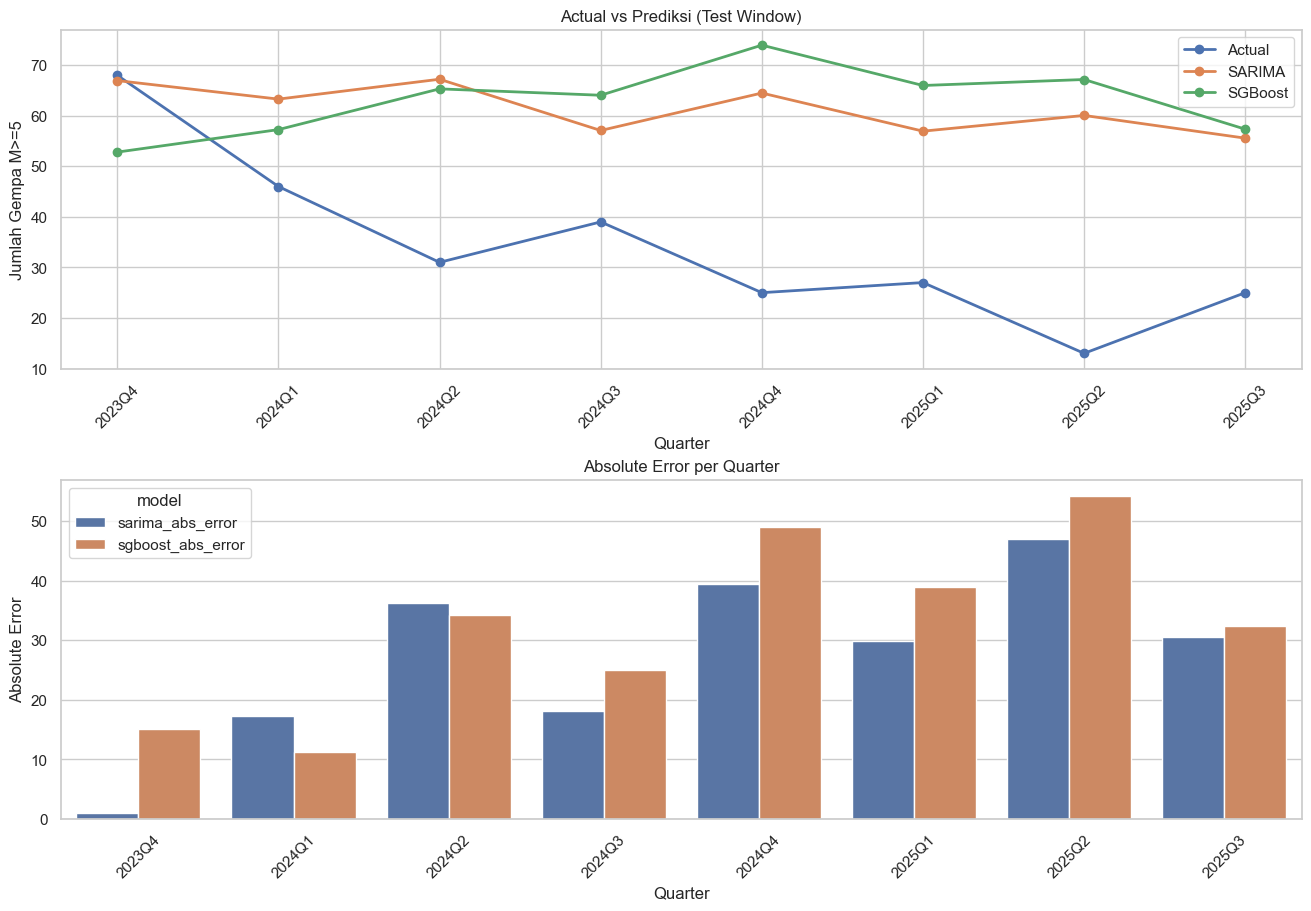

Saved artifacts:
- comparison_plot.png
- metadata.json
- metrics_comparison.csv
- predictions_test.csv
- sarima_model.pkl
- sgboost_model.joblib
- test_split.csv
- train_split.csv


In [32]:
# Visualisasi perbandingan model
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(13, 9), constrained_layout=True)

axes[0].plot(pred_df['quarter'], pred_df['actual'], marker='o', linewidth=2, label='Actual')
axes[0].plot(pred_df['quarter'], pred_df['sarima_pred'], marker='o', linewidth=2, label='SARIMA')
axes[0].plot(pred_df['quarter'], pred_df['sgboost_pred'], marker='o', linewidth=2, label='SGBoost')
axes[0].set_title('Actual vs Prediksi (Test Window)')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Jumlah Gempa M>=5')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

err_plot = pred_df.melt(
    id_vars=['quarter'],
    value_vars=['sarima_abs_error', 'sgboost_abs_error'],
    var_name='model',
    value_name='abs_error'
)
sns.barplot(data=err_plot, x='quarter', y='abs_error', hue='model', ax=axes[1])
axes[1].set_title('Absolute Error per Quarter')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Absolute Error')
axes[1].tick_params(axis='x', rotation=45)

plt.savefig(ARTIFACT_DIR / 'comparison_plot.png', dpi=160, bbox_inches='tight')
plt.show()

print('Saved artifacts:')
for p in sorted(ARTIFACT_DIR.glob('*')):
    print('-', p.name)